# Classificação Supervisionada com Agglomerative Clustering no Dataset Dry Bean

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Agglomerative Clustering, aplicado ao dataset Dry Bean. Todas as etapas são explicadas e o código é comentado para facilitar o entendimento.

## 1. Importação das Bibliotecas

Importamos as bibliotecas necessárias para manipulação de dados, visualização e implementação do Agglomerative Clustering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.cluster.hierarchy import dendrogram, linkage
import os

# Garante que a pasta 'img' existe
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Pré-processamento dos Dados

Carregamos o dataset Dry Bean, removemos valores ausentes, codificamos variáveis categóricas e normalizamos os dados.

In [2]:
# Carregar o dataset Dry Bean
bean_df = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')

# Remover valores ausentes
bean_df = bean_df.dropna()

# Codificar variáveis categóricas
for col in bean_df.select_dtypes(include='object').columns:
    bean_df[col] = LabelEncoder().fit_transform(bean_df[col].astype(str))

# Separar atributos e rótulo
X = bean_df.drop('Class', axis=1).values
y = bean_df['Class'].values

# Normalizar os dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

## 3. Divisão dos Dados em Treino e Teste

Dividimos o conjunto de dados em 70% para treinamento e 30% para teste, garantindo a estratificação das classes.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 4. Definição do Número de Clusters (Método do Cotovelo)

Utilizamos o dendrograma para sugerir o número ideal de clusters.

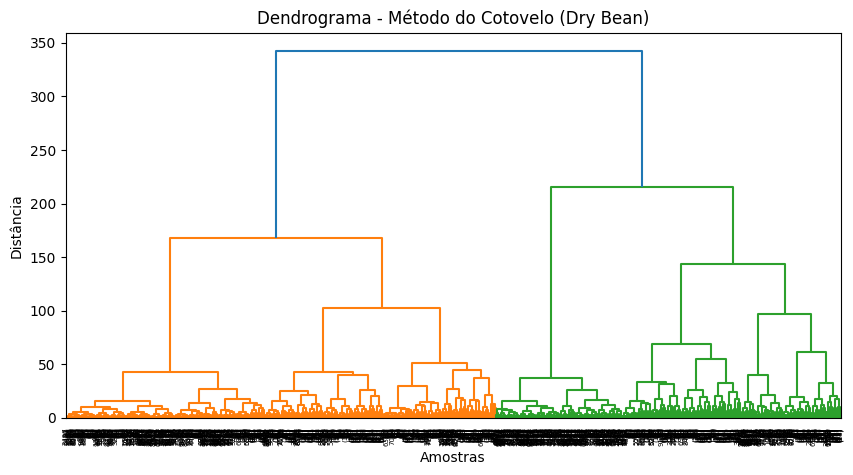

In [4]:
# Garante que a pasta 'img' existe
import os
os.makedirs('img', exist_ok=True)

plt.figure(figsize=(10, 5))
linked = linkage(X_train, method='ward')
dendrogram(linked, truncate_mode='level', p=10)
plt.title('Dendrograma - Método do Cotovelo (Dry Bean)')
plt.xlabel('Amostras')
plt.ylabel('Distância')
plt.savefig('img/agglo_drybean_dendrogram.png')
plt.show()
# Sugestão: escolha visual do número de clusters (exemplo: 7)

## 5. Implementação do Classificador Agglomerative Supervisionado

O classificador associa cada cluster ao rótulo mais frequente no conjunto de treino.

In [5]:
class AggloSupervisionado:
    def __init__(self, n_clusters=2):
        self.n_clusters = n_clusters
        self.agglo = AgglomerativeClustering(n_clusters=n_clusters)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.agglo.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.agglo.fit_predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 6. Treinamento e Avaliação do Classificador

Treinamos o classificador no conjunto de treino e avaliamos no conjunto de teste, mostrando acurácia e matriz de confusão.

Acurácia: 0.2233
Matriz de Confusão:
[[  0   0   0  20 357  17   3]
 [  0 156   0   1   0   0   0]
 [  0   0   2 160 325   2   0]
 [  0   0   0   8  99  18 939]
 [  0   0 452  87  37   0   2]
 [  0   0   0   0   8 525  75]
 [  0   0   6   8 586   7 184]]


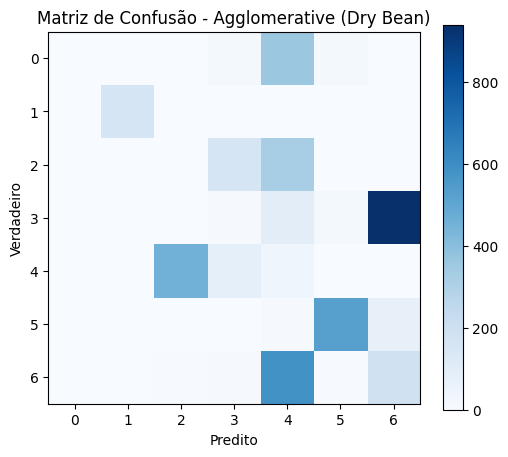

In [6]:
n_clusters = 7  # Ajuste conforme o dendrograma

# Garante que a pasta 'img' existe
import os
os.makedirs('img', exist_ok=True)

clf = AggloSupervisionado(n_clusters=n_clusters)
clf.fit(X_train, y_train)

acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Agglomerative (Dry Bean)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig('img/agglo_drybean_confusion_matrix.png')
plt.show()

## 7. Repetição dos Experimentos

Repita o experimento 30 vezes, variando a semente, e salve as acurácias para análise estatística.

Acurácia média: 0.4522
Desvio padrão: 0.1778


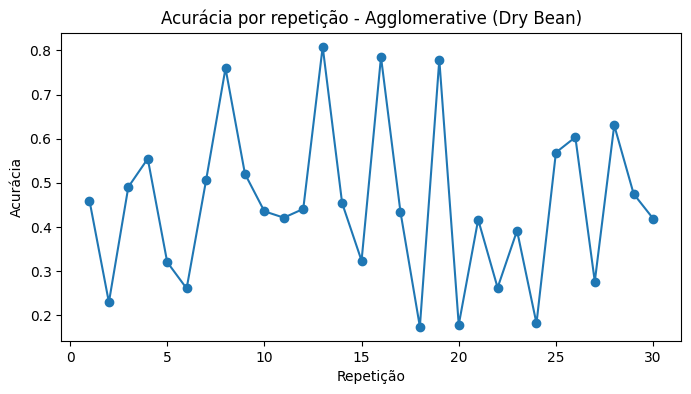

In [7]:
acuracias = []
# Garante que a pasta 'img' existe
import os
os.makedirs('img', exist_ok=True)
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    acc, _ = clf.evaluate(X_test, y_test)
    acuracias.append(acc)

acuracias = np.array(acuracias)
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão: {acuracias.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - Agglomerative (Dry Bean)')
plt.savefig('img/agglo_drybean_accuracy_repetitions.png')
plt.show()

# Salvar acurácias para análise posterior
np.save('img/agglo_drybean_accuracies.npy', acuracias)
np.savetxt('img/agglo_drybean_accuracies.csv', acuracias, delimiter=',')

MSE médio: 3.9144
Desvio padrão do MSE: 1.6197


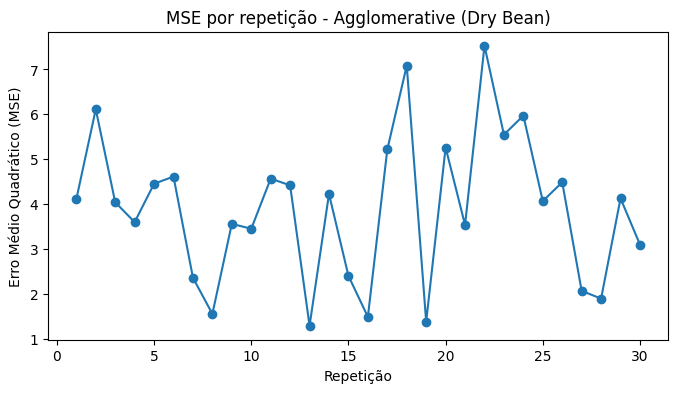

In [8]:
from sklearn.metrics import mean_squared_error

mse_list = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)

mse_array = np.array(mse_list)
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1, 31), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - Agglomerative (Dry Bean)')
plt.savefig('img/agglo_drybean_mse_repetitions.png')
plt.show()

# Salvar MSE para análise posterior
np.save('img/agglo_drybean_mse_repetitions.npy', mse_array)
np.savetxt('img/agglo_drybean_mse_repetitions.csv', mse_array, delimiter=',')

## 8. Análise dos Resultados

Comente os resultados obtidos, destacando a acurácia média, o desvio padrão e possíveis dificuldades do classificador Agglomerative no dataset Dry Bean.

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

accuracies = []
precisions_macro = []
recalls_macro = []
f1s_macro = []
precisions_micro = []
recalls_micro = []
f1s_micro = []
cms = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions_macro.append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    recalls_macro.append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    f1s_macro.append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    precisions_micro.append(precision_score(y_test, y_pred, average='micro', zero_division=0))
    recalls_micro.append(recall_score(y_test, y_pred, average='micro', zero_division=0))
    f1s_micro.append(f1_score(y_test, y_pred, average='micro', zero_division=0))
    cms.append(confusion_matrix(y_test, y_pred))

print('Acurácia média:', np.mean(accuracies))
print('Precisão macro média:', np.mean(precisions_macro))
print('Recall macro médio:', np.mean(recalls_macro))
print('F1-score macro médio:', np.mean(f1s_macro))
print('Precisão micro média:', np.mean(precisions_micro))
print('Recall micro médio:', np.mean(recalls_micro))
print('F1-score micro médio:', np.mean(f1s_micro))
print('Matriz de confusão média:')
print(np.mean(cms, axis=0))

Acurácia média: 0.452154750244858
Precisão macro média: 0.4742591388553293
Recall macro médio: 0.5020217496518247
F1-score macro médio: 0.47581631100081057
Precisão micro média: 0.452154750244858
Recall micro médio: 0.452154750244858
F1-score micro médio: 0.452154750244858
Matriz de confusão média:
[[1.25333333e+02 2.33333333e-01 1.15833333e+02 2.09666667e+01
  1.25433333e+02 2.00000000e+00 7.20000000e+00]
 [0.00000000e+00 1.30833333e+02 0.00000000e+00 5.23333333e+00
  1.04666667e+01 0.00000000e+00 1.04666667e+01]
 [1.39933333e+02 8.00000000e-01 1.49200000e+02 2.58000000e+01
  1.46733333e+02 5.66666667e-01 2.59666667e+01]
 [1.23333333e+00 2.84666667e+01 1.97733333e+02 3.49166667e+02
  1.39200000e+02 2.51333333e+01 3.23066667e+02]
 [6.97666667e+01 5.70000000e+00 1.05466667e+02 4.71000000e+01
  3.06800000e+02 0.00000000e+00 4.31666667e+01]
 [2.06666667e+00 2.66666667e-01 1.27000000e+01 2.70333333e+01
  5.30000000e+00 5.47400000e+02 1.32333333e+01]
 [4.16666667e+00 1.66666667e+00 1.090666

## 9. Cálculo e Interpretação das Métricas de Avaliação
 
Nesta etapa, calculamos as principais métricas de avaliação para problemas multiclasse:
- **Acurácia**: proporção de acertos totais.
- **Precisão, Recall, F1-score (macro/micro)**: médias das métricas considerando todas as classes.
- **Matriz de confusão média**: média das matrizes de confusão das 30 execuções.

Essas métricas permitem avaliar o desempenho do classificador em cenários com múltiplas classes, mostrando não só o acerto global, mas também o equilíbrio entre as classes.

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
def calcular_metricas_multiclasse(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    # Especificidade média: média das especificidades de cada classe
    especificidades = []
    for i in range(cm.shape[0]):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        especificidades.append(especificidade)
    especificidade_media = np.mean(especificidades)
    return acc, prec, rec, especificidade_media, f1, cm

# Repetição para obter métricas médias
accs, precs, recs, especificidades, f1s, cms = [], [], [], [], [], []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc, prec, rec, esp, f1, cm = calcular_metricas_multiclasse(y_test, y_pred)
    accs.append(acc)
    precs.append(prec)
    recs.append(rec)
    especificidades.append(esp)
    f1s.append(f1)
    cms.append(cm)

print(f'Acurácia média: {np.mean(accs):.4f}')
print(f'Precisão média: {np.mean(precs):.4f}')
print(f'Recall médio: {np.mean(recs):.4f}')
print(f'Especificidade média: {np.mean(especificidades):.4f}')
print(f'F1-score médio: {np.mean(f1s):.4f}')
print('Matriz de confusão média:')
print(np.mean(cms, axis=0).round(2))

Acurácia média: 0.4522
Precisão média: 0.4743
Recall médio: 0.5020
Especificidade média: 0.9056
F1-score médio: 0.4758
Matriz de confusão média:
[[1.2533e+02 2.3000e-01 1.1583e+02 2.0970e+01 1.2543e+02 2.0000e+00
  7.2000e+00]
 [0.0000e+00 1.3083e+02 0.0000e+00 5.2300e+00 1.0470e+01 0.0000e+00
  1.0470e+01]
 [1.3993e+02 8.0000e-01 1.4920e+02 2.5800e+01 1.4673e+02 5.7000e-01
  2.5970e+01]
 [1.2300e+00 2.8470e+01 1.9773e+02 3.4917e+02 1.3920e+02 2.5130e+01
  3.2307e+02]
 [6.9770e+01 5.7000e+00 1.0547e+02 4.7100e+01 3.0680e+02 0.0000e+00
  4.3170e+01]
 [2.0700e+00 2.7000e-01 1.2700e+01 2.7030e+01 5.3000e+00 5.4740e+02
  1.3230e+01]
 [4.1700e+00 1.6700e+00 1.0907e+02 3.6203e+02 6.6630e+01 9.5700e+00
  2.3787e+02]]


## 9. Cálculo das Principais Métricas de Avaliação
Nesta etapa, calculamos e exibimos as principais métricas de avaliação do classificador: acurácia, precisão, recall, especificidade, F1-score e matriz de confusão média. Essas métricas permitem uma análise quantitativa detalhada do desempenho do modelo em múltiplas classes.